### В этом блокноте проводится EDA для корпуса данных TIMIT для построения основных зависимостей и распределений

Импорт библиотек

In [ ]:
import os
import pandas as pd
import re
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
import seaborn as sns
import librosa
from pathlib import Path

Загрузка датасета

Table of speakers/speaker information used in DARPA TIMIT Acoustic-Phonetic;
Speech Corpus.  Lines beginning with a semicolon are comments and should be; ignored on searches.

- ID - Speaker initials (of form AAAN where 'A' is alphabetic initial and 'N'
                        is a digit 0-9 to disambiguate identical initials)  
- Sex - Speaker gender (M or F)  
- DR - Speaker dialect region number (1 - New England   
                                     2 - Northern  
                                     3 - North Midland  
                                     4 - South Midland  
                                     5 - Southern  
                                     6 - New York City  
                                     7 - Western  
                                     8 - Army Brat (moved around))   
- Use - Data usage (TRN - System training speaker  
                   TST - System test speaker)  
- RecDate - Recording date  
- BirthDate - Speaker birth date  
- Ht - Speaker height  
- Race - Speaker race (WHT - White  
                      BLK - Black  
                      AMR - American Indian  
                      SPN - Spanish-American  
                      ORN - Oriental  
                      ??? - Unknown)  
- Edu - Speaker education level (HS - High School  
                                AS - Associate Degree  
                                BS - Bachelor's Degree (BS or BA)  
                                MS - Master's Degree (MS or MA)  
                                PHD - Doctorate Degree (PhD, JD, or MD)  
                                ?? - Unknown)  

- Comments - Interesting speaker attributes or abnormalities

In [ ]:
csv_path = './darpa-timit-acousticphonetic-continuous-speech/versions/6/train_data.csv'

In [124]:
df = pd.read_csv(csv_path)
df.head()

,index,test_or_train,dialect_region,speaker_id,filename,path_from_data_dir,path_from_data_dir_windows,is_converted_audio,is_audio,is_word_file,is_phonetic_file,is_sentence_file
0,1.0,TRAIN,DR4,MMDM0,SI681.WAV.wav,TRAIN/DR4/MMDM0/SI681.WAV.wav,TRAIN\\DR4\\MMDM0\\SI681.WAV.wav,True,True,False,False,False
1,2.0,TRAIN,DR4,MMDM0,SI1311.PHN,TRAIN/DR4/MMDM0/SI1311.PHN,TRAIN\\DR4\\MMDM0\\SI1311.PHN,False,False,False,True,False
2,3.0,TRAIN,DR4,MMDM0,SI1311.WRD,TRAIN/DR4/MMDM0/SI1311.WRD,TRAIN\\DR4\\MMDM0\\SI1311.WRD,False,False,True,False,False
3,4.0,TRAIN,DR4,MMDM0,SX321.PHN,TRAIN/DR4/MMDM0/SX321.PHN,TRAIN\\DR4\\MMDM0\\SX321.PHN,False,False,False,True,False
4,5.0,TRAIN,DR4,MMDM0,SX321.WRD,TRAIN/DR4/MMDM0/SX321.WRD,TRAIN\\DR4\\MMDM0\\SX321.WRD,False,False,True,False,False


In [ ]:
file_path = './darpa-timit-acousticphonetic-continuous-speech/versions/6/SPKRINFO.TXT'

In [ ]:
def parse_sprkinfo(file_path):
    """Парсит файл SPKRINFO.TXT TIMIT"""
    
    data = []
    in_data_section = False
    line_num = 0
    
    with open(file_path, 'r') as f:
        for line in f:
            line_num += 1
            line = line.rstrip()
            
            # Ищем начало таблицы
            if ';ID  Sex DR Use' in line:
                in_data_section = True
                continue
            
            # Пропускаем комментарии
            if line.startswith(';'):
                continue
            
            # Пропускаем разделители
            if line.startswith('--') or not line.strip():
                continue
            
            # Парсим строки данных
            if in_data_section:
                
                parts = re.split(r'\s{2,}', line.strip())
                
                if len(parts) >= 9:
                    # Убираем лишние пробелы в каждом поле
                    row = [p.strip() for p in parts[:9]]
                    
                    # Если есть комментарий (10+ поле)
                    if len(parts) > 9:
                        comment = ' '.join(parts[9:]).strip()
                        row.append(comment)
                    else:
                        row.append('')
                    
                    data.append(row)
                else:
                    print(f"Строка {line_num}: неполная - {parts}")
    
    return data

# Загрузка
data = parse_sprkinfo(file_path)

columns = ['ID', 'Sex', 'DR', 'Use', 'RecDate', 'BirthDate', 'Ht', 'Race', 'Edu', 'Comments']
df = pd.DataFrame(data, columns=columns)

print(f"Загружено строк: {len(df)}")
print(f"Ожидается: ~630 строк")

if len(df) > 0:
    print("\nСтатистика:")
    print(f"Уникальных ID: {df['ID'].nunique()}")
    print(f"Значения DR: {sorted(df['DR'].unique())}")
    print(f"Значения Use: {df['Use'].value_counts().to_dict()}")
    
    # Покажем пример
    print("\nПример записи:")
    print(df.iloc[0].to_dict())

Загружено строк: 630
Ожидается: ~630 строк

Статистика:
Уникальных ID: 630
Значения DR: ['1', '2', '3', '4', '5', '6', '7', '8']
Значения Use: {'TRN': 462, 'TST': 168}

Пример записи:
{'ID': 'ABC0', 'Sex': 'M', 'DR': '6', 'Use': 'TRN', 'RecDate': '03/03/86', 'BirthDate': '06/17/60', 'Ht': '5\'11"', 'Race': 'WHT', 'Edu': 'BS', 'Comments': ''}


In [162]:
df.shape

(630, 10)

In [164]:
df.head(10)

,ID,Sex,DR,Use,RecDate,BirthDate,Ht,Race,Edu,Comments
0,ABC0,M,6,TRN,03/03/86,06/17/60,"5'11""",WHT,BS,
1,ABW0,M,2,TST,04/21/86,05/26/59,"5'9""",WHT,BS,
2,ADC0,M,3,TRN,02/25/86,04/27/54,"5'9""",WHT,HS,
3,ADD0,M,7,TRN,01/28/86,03/23/58,"6'2""",WHT,BS,
4,ADG0,F,4,TST,02/12/86,04/11/59,"5'4""",WHT,MS,
5,AEB0,M,4,TRN,04/10/86,09/20/37,"5'11""",WHT,HS,
6,AEM0,F,2,TRN,02/27/86,05/13/60,"5'3""",WHT,BS,
7,AEO0,M,7,TRN,02/20/86,07/19/55,"5'11""",WHT,BS,
8,AFM0,M,7,TRN,03/31/86,12/22/52,"5'08""",WHT,BS,
9,AHH0,M,5,TST,02/14/86,02/22/53,"5'10""",BLK,BS,


Распределение по возрасту

/tmp/ipykernel_1141256/1372049008.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['BirthDate_dt'] = pd.to_datetime(df['BirthDate'], format='%m/%d/%y')
/tmp/ipykernel_1141256/1372049008.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['RecDate_dt'] = pd.to_datetime(df['RecDate'], format='%m/%d/%y')
/tmp/ipykernel_1141256/1372049008.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the ca

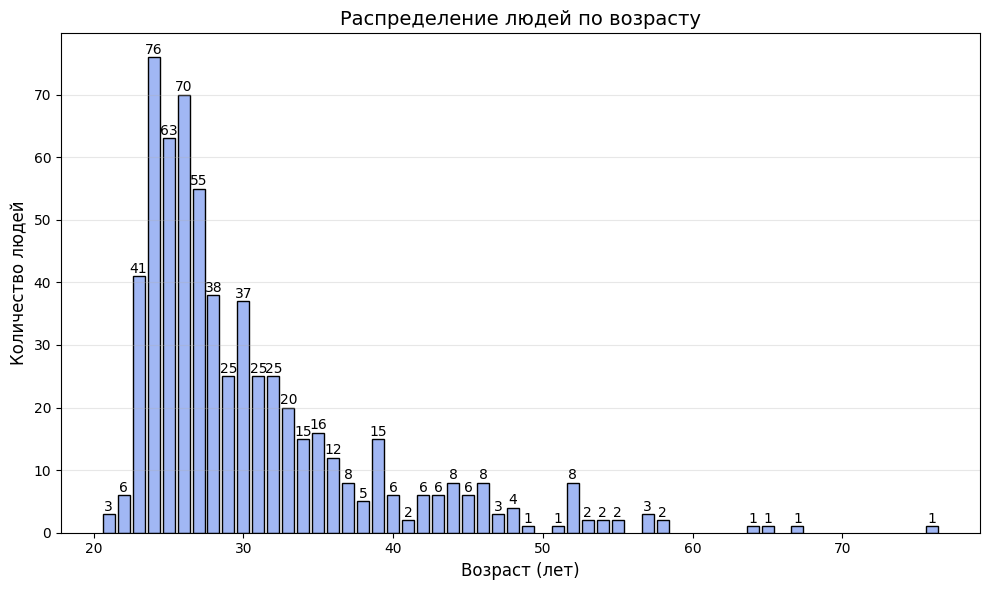


Статистика:
Всего людей: 629
Возрастной диапазон: 21-76 лет
Средний возраст: 30.4 лет


In [ ]:
df = df[~df['BirthDate'].str.contains('\?\?', na=False)]

df['BirthDate_dt'] = pd.to_datetime(df['BirthDate'], format='%m/%d/%y')
df['RecDate_dt'] = pd.to_datetime(df['RecDate'], format='%m/%d/%y')

# Корректируем двухзначные годы в BirthDate_dt
# Если дата рождения позже даты записи, вычитаем 100 лет
mask_wrong_century = df['BirthDate_dt'] > df['RecDate_dt']
df.loc[mask_wrong_century, 'BirthDate_dt'] = df.loc[mask_wrong_century, 'BirthDate_dt'] - pd.DateOffset(years=100)
df.loc[~mask_wrong_century, 'BirthDate_dt'] = df.loc[~mask_wrong_century, 'BirthDate_dt']

# Создаем колонку с вычисленным возрастом (используем исправленную дату рождения)
df['Age'] = (df['RecDate_dt'] - df['BirthDate_dt']).dt.days / 365.25

# Остальной код остается без изменений
df['Age_rounded'] = df['Age'].round().astype(int)

age_counts = df['Age_rounded'].value_counts().sort_index()

# График
plt.figure(figsize=(10, 6))
plt.bar(age_counts.index, age_counts.values, color='#A1B7F4', edgecolor='black')
plt.xlabel('Возраст (лет)', fontsize=12)
plt.ylabel('Количество людей', fontsize=12)
plt.title('Распределение людей по возрасту', fontsize=14)
plt.grid(True, alpha=0.3, axis='y')

for age, count in age_counts.items():
    plt.text(age, count + 0.05, str(count), ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Статистика
print(f"\nСтатистика:")
print(f"Всего людей: {len(df)}")
print(f"Возрастной диапазон: {df['Age_rounded'].min()}-{df['Age_rounded'].max()} лет")
print(f"Средний возраст: {df['Age'].mean():.1f} лет")

In [167]:
df.head()

,ID,Sex,DR,Use,RecDate,BirthDate,Ht,Race,Edu,Comments,BirthDate_dt,RecDate_dt,Age,Age_rounded
0,ABC0,M,6,TRN,03/03/86,06/17/60,"5'11""",WHT,BS,,1960-06-17,1986-03-03,25.708419,26
1,ABW0,M,2,TST,04/21/86,05/26/59,"5'9""",WHT,BS,,1959-05-26,1986-04-21,26.904860,27
2,ADC0,M,3,TRN,02/25/86,04/27/54,"5'9""",WHT,HS,,1954-04-27,1986-02-25,31.832991,32
3,ADD0,M,7,TRN,01/28/86,03/23/58,"6'2""",WHT,BS,,1958-03-23,1986-01-28,27.852156,28
4,ADG0,F,4,TST,02/12/86,04/11/59,"5'4""",WHT,MS,,1959-04-11,1986-02-12,26.841889,27


Распределение по полу и возрасту

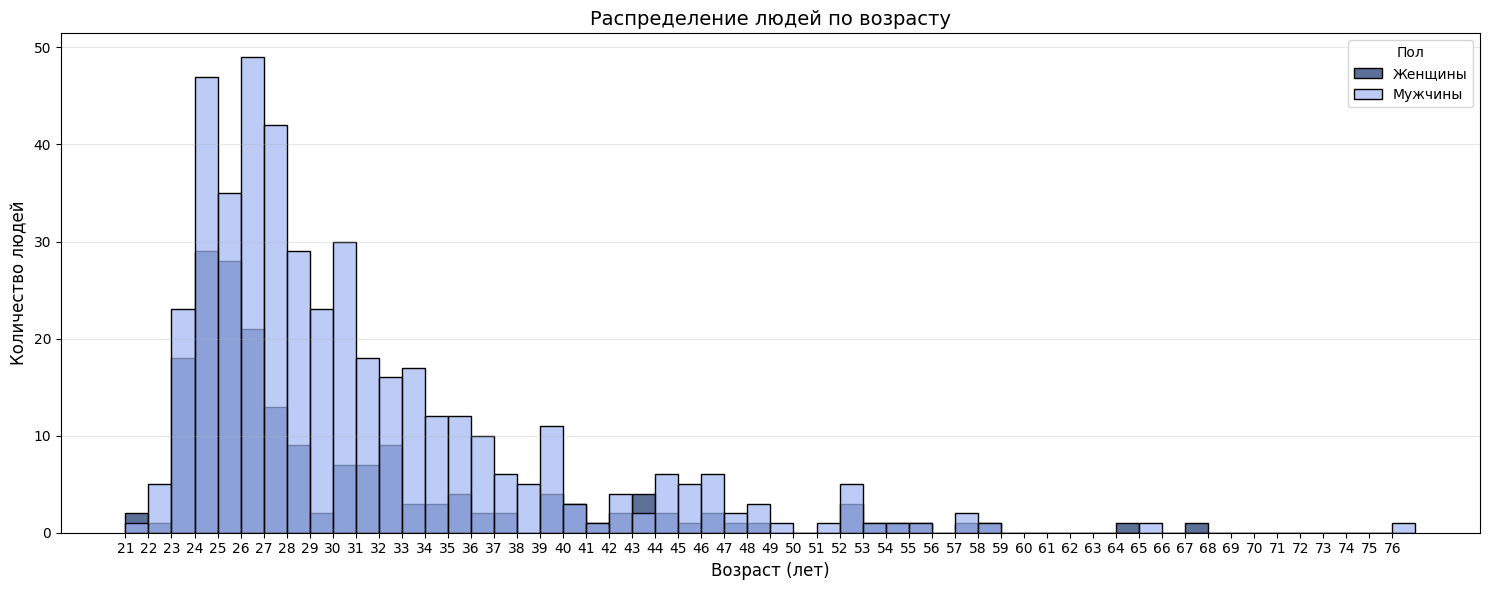

In [170]:
# Гистограмма с hue по полу
plt.figure(figsize=(15, 6))
sns.histplot(data=df, x='Age_rounded', hue='Sex', 
             bins=range(df['Age_rounded'].min(), df['Age_rounded'].max() + 2),
             palette=['#A1B7F4', '#17346D'],
             alpha=0.7,
             edgecolor='black')

plt.xlabel('Возраст (лет)', fontsize=12)
plt.ylabel('Количество людей', fontsize=12)
plt.title('Распределение людей по возрасту', fontsize=14)
plt.grid(True, alpha=0.3, axis='y')
plt.xticks(range(df['Age_rounded'].min(), df['Age_rounded'].max() + 1))
plt.legend(title='Пол', labels=['Женщины', 'Мужчины'])
plt.tight_layout()
plt.show()

Распределение по полу

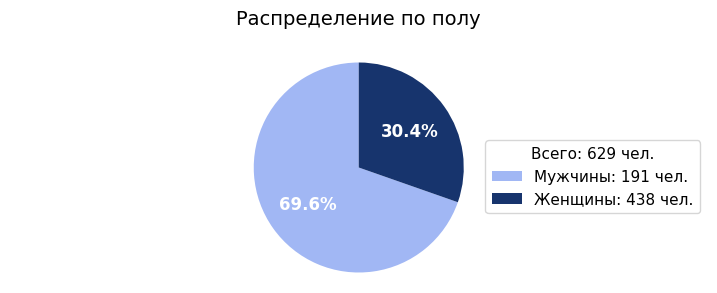

In [171]:
gender_counts = df['Sex'].value_counts()

plt.figure(figsize=(9, 3))

colors = ['#A1B7F4', "#17346D"]
wedges, texts, autotexts = plt.pie(gender_counts.values, 
                                    labels=None,
                                    colors=colors,
                                    autopct='%1.1f%%',
                                    startangle=90,
                                    textprops={'fontsize': 12, 'color': 'white', 'fontweight': 'bold'})

plt.legend(wedges, 
           [f'Мужчины: {gender_counts.get("F", 0)} чел.', 
            f'Женщины: {gender_counts.get("M", 0)} чел.'],
           loc='upper right',
           bbox_to_anchor=(1, 0.65),  # Координаты внутри графика
           frameon=True,
           fontsize=11,
           title=f'Всего: {len(df)} чел.',
           title_fontsize=11)

plt.title('Распределение по полу', loc = 'center', fontsize=14, pad=20)
plt.axis('equal')
plt.show()

Поссчитаем количество уникальных спикеров

In [172]:
df.shape

(629, 14)

In [173]:
df['ID'].nunique()

629

Распределение по длительности

Найдено 6300 WAV файлов


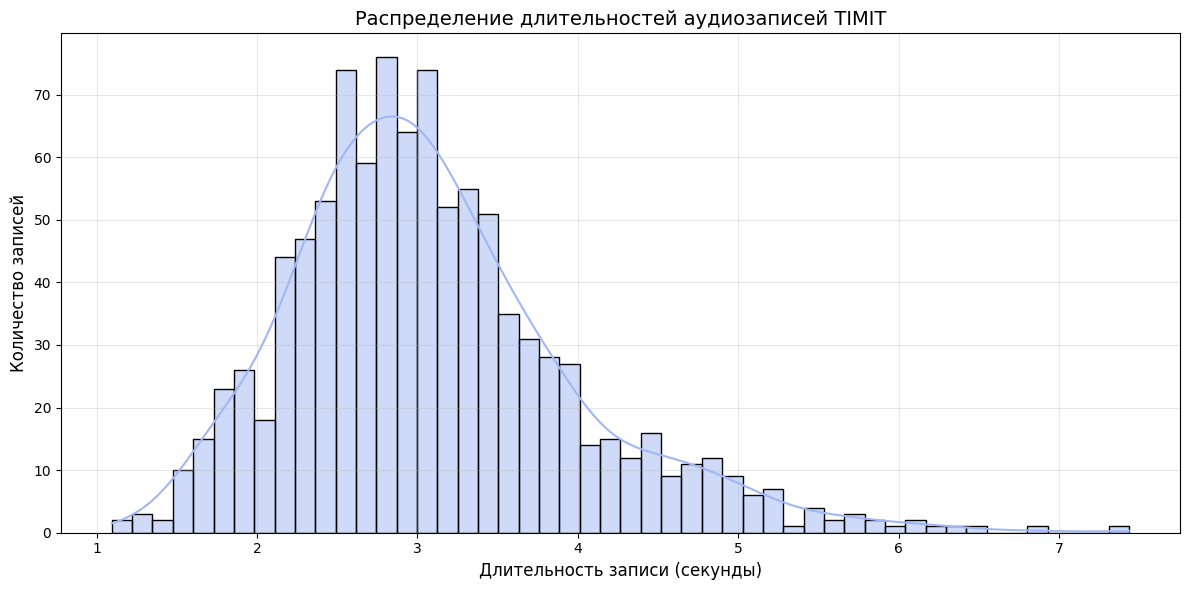

Минимальная длительность: 1.09 сек
Максимальная длительность: 7.44 сек
Средняя длительность: 3.09 сек
Медианная длительность: 2.97 сек


In [ ]:
# Путь к TIMIT
timit_path = "./darpa-timit-acousticphonetic-continuous-speech/versions/6"

# Собираем все WAV файлы
wav_files = []
for wav_path in Path(timit_path).rglob('*.WAV'):
    wav_files.append(str(wav_path))

print(f"Найдено {len(wav_files)} WAV файлов")

# Считываем длительности
durations = []
for wav_file in wav_files[:1000]:  # Ограничим для скорости
    try:
        duration = librosa.get_duration(path=wav_file)
        durations.append(duration)
    except:
        continue

# Строим гистограмму
plt.figure(figsize=(12, 6))
sns.histplot(durations, bins=50, kde=True, color='#A1B7F4')
plt.xlabel('Длительность записи (секунды)', fontsize=12)
plt.ylabel('Количество записей', fontsize=12)
plt.title('Распределение длительностей аудиозаписей TIMIT', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Статистика
print(f"Минимальная длительность: {min(durations):.2f} сек")
print(f"Максимальная длительность: {max(durations):.2f} сек")
print(f"Средняя длительность: {np.mean(durations):.2f} сек")
print(f"Медианная длительность: {np.median(durations):.2f} сек")

### Выводы
#### При проведении первичного анализа набора данных TIMIT были выявлены следующие закономерности:
- Возрастной диапазон колеблется от 21 до 76 лет;
- Наблюдается недостаток данных среди лиц пожилого возраста, детские голоса в базе отсутствуют;
- В выборке преобладают мужские голоса, которые  составляют 69% от общего количества;
- При анализе распределения длительностей аудиозаписей выявлено, что средняя продолжительность составляет 3 секунды, а сами длительности колеблются от 1.09 с. до 7.44 с.